Al conversar con el cliente (la empresa) llegamos a la conclusión de que la pregunta y objetivo está en la siguiente frase: 
"Quiero poder predecir qué productos se venderán más en los próximos 3 meses para así poder invertir en el stock de esos productos."

Esto implica que es necesaria una predicción por mes de los productos. 
Con un horizonte temporal de 3 meses, es decir, proyectar 3 meses más del último dato.

Después de la obtención de los datos con el negocio se obtuvo un conjunto de datos considerables para realizar el análisis. Por tanto se procede a realizar un *EDA*:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
#Ahora cargamos el dataset y se guarda en un tipo de variable dataframe

df = pd.read_csv("../ventas_empresa_logistica.csv")
#Observamos las primeras filas del dataset con el método head()
print(df.head())

        fecha         producto  categoria  cantidad  precio_unitario medida  \
0  2023-03-26            Pollo     Granos         5             0.95     kg   
1  2023-11-06  Pasta de Tomate    Lácteos         2             1.50      u   
2  2023-07-21           Bolsas  Panadería         4             0.35      u   
3  2024-09-09            Pollo     Granos         4             0.95     kg   
4  2024-10-25            Pollo     Granos         2             0.95     kg   

   total  
0   4.75  
1   3.00  
2   1.40  
3   3.80  
4   1.90  


In [2]:
print(df)

            fecha            producto  categoria  cantidad  precio_unitario  \
0      2023-03-26               Pollo     Granos         5             0.95   
1      2023-11-06     Pasta de Tomate    Lácteos         2             1.50   
2      2023-07-21              Bolsas  Panadería         4             0.35   
3      2024-09-09               Pollo     Granos         4             0.95   
4      2024-10-25               Pollo     Granos         2             0.95   
...           ...                 ...        ...       ...              ...   
15228  2024-02-26        Leche entera     Granos         3             5.00   
15229  2023-05-22  Papas precocinadas    Lácteos         4             3.15   
15230  2023-06-11     Pasta de Tomate    Lácteos         2             1.50   
15231  2024-06-28        Leche entera     Granos         1             5.00   
15232  2024-06-10        Leche entera     Granos         3             5.00   

      medida  total  
0         kg   4.75  
1      

In [3]:
dates = [df["fecha"].max(),df["fecha"].min()]
print(dates)

['2024-12-01', '2023-03-01']


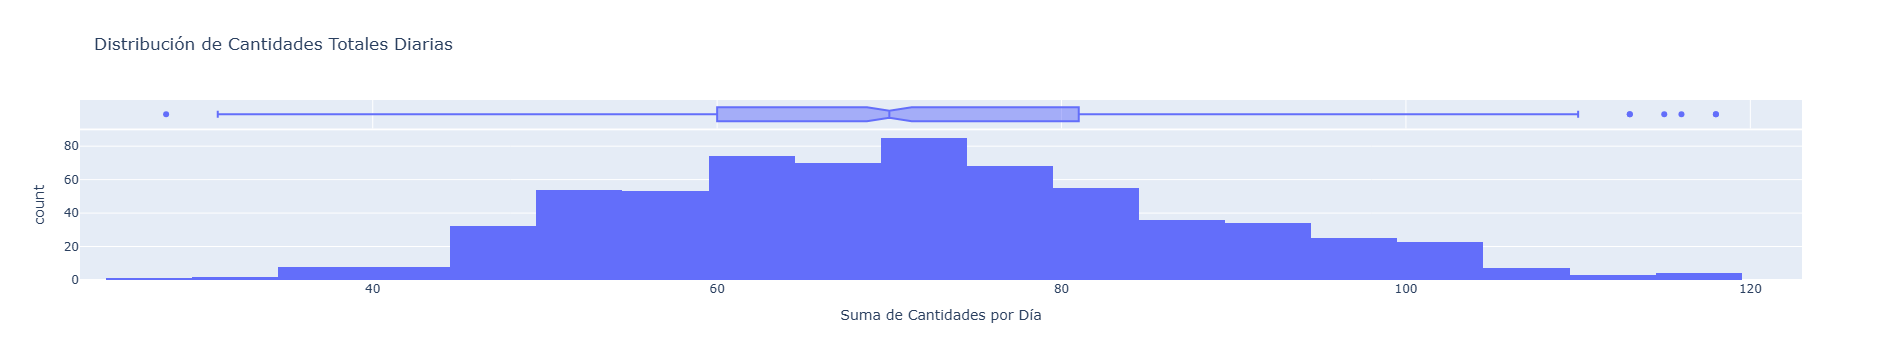

In [4]:
import plotly.express as px
# Agrupar por fecha para ver la distribución de ventas diarias
df_diario = df.groupby('fecha')['cantidad'].sum().reset_index()

fig = px.histogram(
    df_diario, 
    x="cantidad", 
    marginal="box",
    title="Distribución de Cantidades Totales Diarias",
    labels={'cantidad': 'Suma de Cantidades por Día'}
)
fig.show()

Existe normalidad, aunque con sesgo hacia la izquierda pero no demasiado visualmente. Sin embargo se ve la presencia de posibles outliars, se requiere tratamiento a esos datos.

Taking a look with box plots:

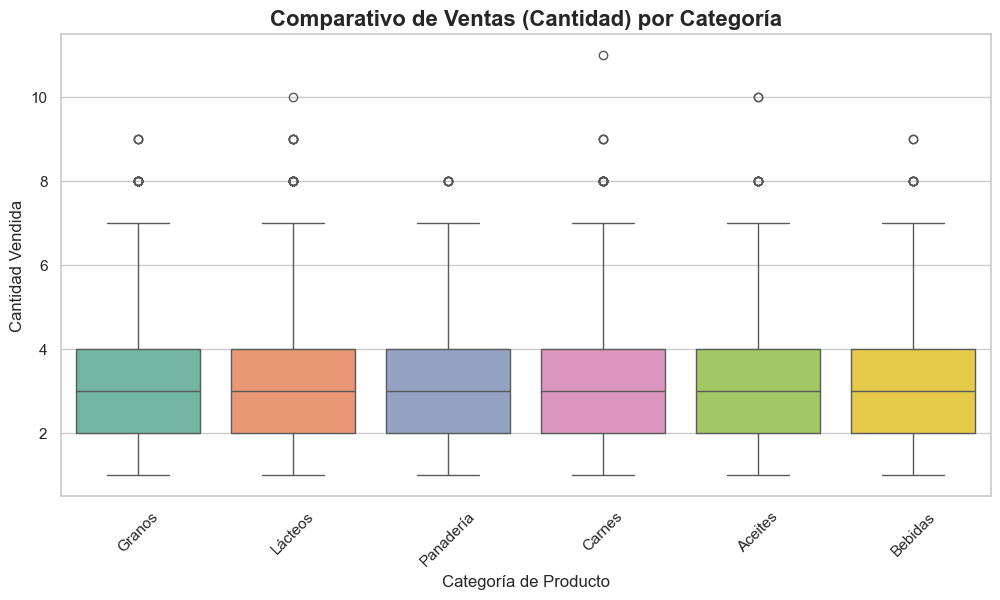

In [5]:
#Versión 0.1 de este análisis de boxplots
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Establezco el estilo
sns.set_theme(style="whitegrid")

# 2. Creamos el gráfico comparativo de boxplots
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='categoria',           # Eje X: Las categorías
    y='cantidad',            # Eje Y: La cantidad de ventas
    data=df,                 # Usamos el DF original para tener los nombres de las categorías
    hue='categoria',         # Diferenciamos colores por categoría
    palette='Set2',          # Paleta de colores suaves y profesionales
    legend=False             # Quitamos la leyenda porque ya tenemos los nombres en el eje X
)

# 3. Personalización profesional
plt.title('Comparativo de Ventas (Cantidad) por Categoría', fontsize=16, fontweight='bold')
plt.xlabel('Categoría de Producto', fontsize=12)
plt.ylabel('Cantidad Vendida', fontsize=12)
plt.xticks(rotation=45)     # Rotamos los nombres si son muy largos para que no se amontonen

plt.show()

In [6]:
#Dado que encontré posibles outliers los voy a filtrar para visualizar y analizarlos
df_highPerformance = df [(df["cantidad"] > df["cantidad"].quantile(0.95))]
df_highPerformance

,fecha,producto,categoria,cantidad,precio_unitario,medida,total
17,2023-06-13,Carne molida,Aceites,7,0.80,kg,5.60
179,2024-07-30,Pasta de Tomate,Lácteos,9,1.50,u,13.50
271,2024-10-30,Helado,Lácteos,7,1.10,u,7.70
381,2024-02-24,Carne molida,Aceites,7,0.80,kg,5.60
388,2024-07-08,Bolsas,Panadería,7,0.35,u,2.45
...,...,...,...,...,...,...,...
15042,2023-09-06,Leche entera,Granos,7,5.00,u,35.00
15088,2024-05-09,Papas precocinadas,Lácteos,8,3.15,u,25.20
15103,2023-05-15,Carne molida,Aceites,8,0.80,kg,6.40
15164,2024-05-19,Jamón,Carnes,7,0.90,kg,6.30


Confirmo presencia de Outliars pero son valores reales de ventas registrados. Le daré tratamiento apenas elimine nulos y duplicados.

### En esta sección comprobaremos linealidad de los datos:

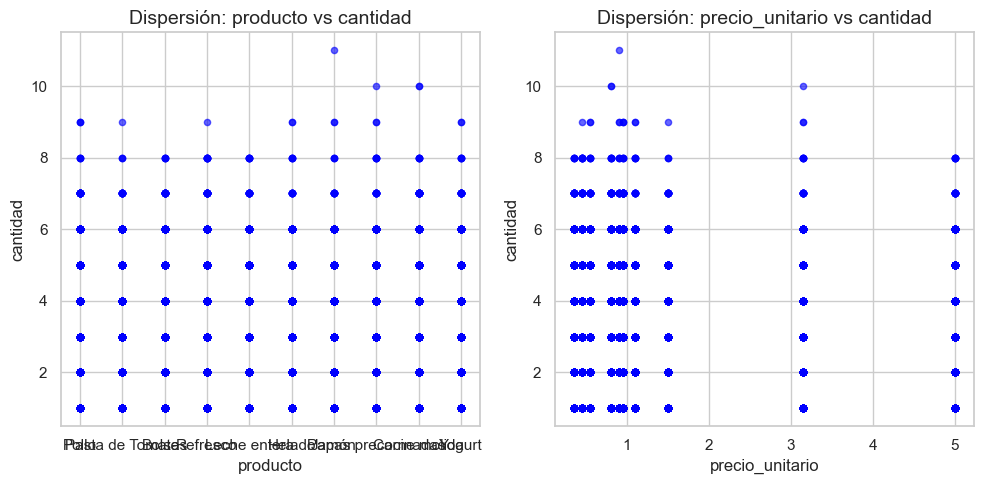

In [7]:
#REVISAR ESTO; NO ENTIENDO NI SIRVE PARA QUÉ??????
target_variable = 'cantidad'
predictor_variables = ['producto', 'precio_unitario']

plt.figure(figsize=(5*2, 5))

for i, feature in enumerate(predictor_variables):


    ##Subplot  (Filas, columnas, posición)
    plt.subplot(1, 2, i + 1)

    #Generamos el grafico de dispersión Scatter plot
    #x = datos de la variable predictora,  y = datos de target
    plt.scatter(df[feature],df[target_variable], alpha=0.6, s= 20, color='blue')

    # 3. Añadimos títulos y etiquetas
    plt.title(f'Dispersión: {feature} vs {target_variable}', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel(target_variable, fontsize=12)
    
    # 3. Añadimos títulos y etiquetas
    plt.title(f'Dispersión: {feature} vs {target_variable}', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel(target_variable, fontsize=12)

# Ajusta automáticamente los parámetros del subplot para que encajen en el área de la figura
plt.tight_layout()
plt.show()


In [8]:
#Mostramos las últimas filas del dataset con método tail()
print(df.tail())

            fecha            producto categoria  cantidad  precio_unitario  \
15228  2024-02-26        Leche entera    Granos         3             5.00   
15229  2023-05-22  Papas precocinadas   Lácteos         4             3.15   
15230  2023-06-11     Pasta de Tomate   Lácteos         2             1.50   
15231  2024-06-28        Leche entera    Granos         1             5.00   
15232  2024-06-10        Leche entera    Granos         3             5.00   

      medida  total  
15228      u   15.0  
15229      u   12.6  
15230      u    3.0  
15231      u    5.0  
15232      u   15.0  


In [9]:
#Para conocer la envergadura o tamaño del dataset accediendo al atributo .shape
print("Tenemos un total de",df.shape[0],"Columnas y un total de", df.shape [1], "Filas.")

Tenemos un total de 15233 Columnas y un total de 7 Filas.


In [10]:
#Este método .info() nos es útil para ver un pequeño resumen del dataset y adicionalmente vemos si hay nulos
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15233 entries, 0 to 15232
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fecha            15233 non-null  object 
 1   producto         15233 non-null  object 
 2   categoria        15233 non-null  object 
 3   cantidad         15233 non-null  int64  
 4   precio_unitario  15233 non-null  float64
 5   medida           15233 non-null  object 
 6   total            15233 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 833.2+ KB
None


La no existencia de nulos es positivo, ahora, consultemos la existencia de elementos repetidos:

In [11]:
#Para ello seguimos usando el dataframe.
print(df.duplicated().sum())

3130


Tenemos un total de 3130 filas duplicadas (sin contar la primera aparición) en todo el dataframe. Veamos estas filas para luego eliminarlas:

In [12]:
print(df[df.duplicated(keep=False)])

            fecha         producto  categoria  cantidad  precio_unitario  \
1      2023-11-06  Pasta de Tomate    Lácteos         2             1.50   
2      2023-07-21           Bolsas  Panadería         4             0.35   
3      2024-09-09            Pollo     Granos         4             0.95   
5      2023-04-02         Refresco     Carnes         3             0.45   
7      2023-10-25           Bolsas  Panadería         2             0.35   
...           ...              ...        ...       ...              ...   
15225  2024-05-12            Jamón     Carnes         3             0.90   
15227  2023-04-13     Leche entera     Granos         2             5.00   
15228  2024-02-26     Leche entera     Granos         3             5.00   
15230  2023-06-11  Pasta de Tomate    Lácteos         2             1.50   
15232  2024-06-10     Leche entera     Granos         3             5.00   

      medida  total  
1          u   3.00  
2          u   1.40  
3         kg   3.80  

In [13]:
df = df.drop_duplicates()

#Consultamos si quedan duplicados ahora:
#Para ello seguimos usando el dataframe.
print(df.duplicated().sum())

0


Observamos los productos más vendidos (por cantidad)

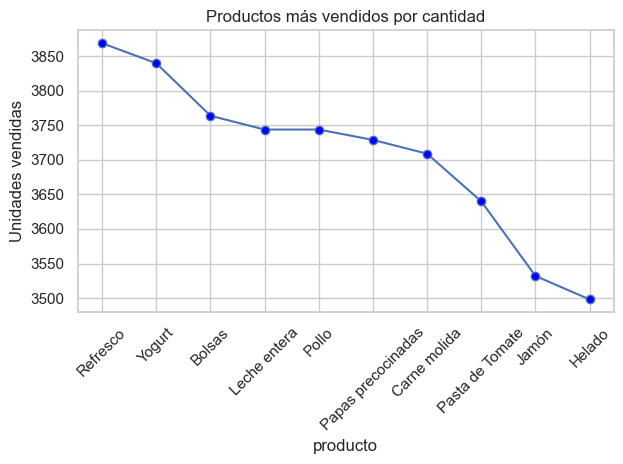

In [20]:
import matplotlib.pyplot as plt
#Creamos un gráfico para visualizar los productos más vendidos (por cantidad)
top_productos = df.groupby("producto")["cantidad"].sum().sort_values(ascending=False)
ax = top_productos.plot(
    kind="line",
    marker="o",
    markersize=6,
    markerfacecolor="blue",
    title="Productos más vendidos por cantidad",
    ylabel="Unidades vendidas"
)

# Mostrar todas las etiquetas del eje X
ax.set_xticks(range(len(top_productos)))
ax.set_xticklabels(top_productos.index, rotation=45)

plt.tight_layout()  # Ajustar el diseño para que no se corte nada
plt.show()

Tratamiento a outliers usando una columna logarítmica:

In [14]:
import numpy as np

#Aquí crearé la columna nueva
df["cantidad_log"] = np.log1p(df["cantidad"])


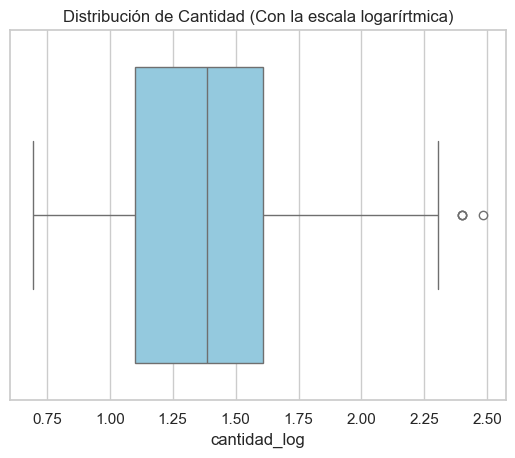

In [15]:
#Veamos el resultado de cómo se ve ahora: 
#uso nuevamente seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.boxplot(x=df["cantidad_log"], color = "skyblue")
plt.title('Distribución de Cantidad (Con la escala logarírtmica)')
plt.show()

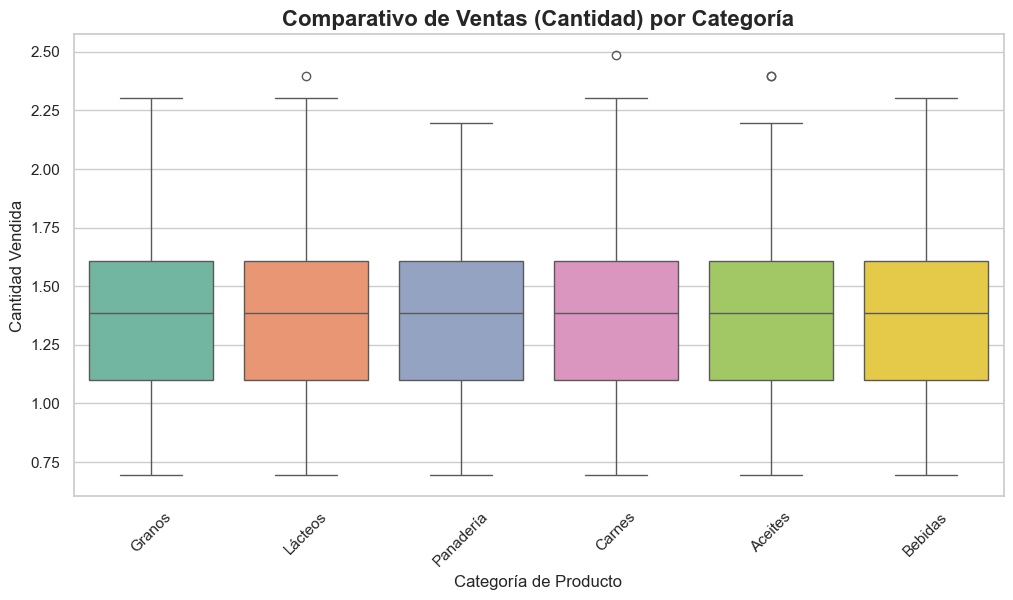

In [16]:
#Versión 0.1 de este análisis de boxplots
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Establezco el estilo
sns.set_theme(style="whitegrid")

# 2. Creamos el gráfico comparativo de boxplots
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='categoria',           # Eje X: Las categorías
    y='cantidad_log',            # Eje Y: La cantidad de ventas
    data=df,                 # Usamos el DF original para tener los nombres de las categorías
    hue='categoria',         # Diferenciamos colores por categoría
    palette='Set2',          # Paleta de colores suaves y profesionales
    legend=False             # Quitamos la leyenda porque ya tenemos los nombres en el eje X
)

# 3. Personalización profesional
plt.title('Comparativo de Ventas (Cantidad) por Categoría', fontsize=16, fontweight='bold')
plt.xlabel('Categoría de Producto', fontsize=12)
plt.ylabel('Cantidad Vendida', fontsize=12)
plt.xticks(rotation=45)     # Rotamos los nombres si son muy largos para que no se amontonen

plt.show()

Después de la transformación logarítmica de la variable "cantidad", 
observo menos outliers y más estabilidad en los valores.

Considero una opción tratarlos con un techo estadístico, con esto no pierdo valores de los datos y además estarían más estables para el modelo de regresión lineal.


In [17]:
#Primero visualicemos esos datos extremos
# Calculamos el límite superior del boxplot
Q1 = df['cantidad_log'].quantile(0.25)
Q3 = df['cantidad_log'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# Filtramos los que REALMENTE son outliers según el gráfico
df_extremos = df[df['cantidad_log'] > limite_superior]

# Creamos el dataframe limpio (sin esos puntos)
df_limpio = df[df['cantidad_log'] <= limite_superior]

print(f"Datos originales: {len(df)}")
print(f"Outliers detectados: {len(df_extremos)}")

Datos originales: 12103
Outliers detectados: 4


In [18]:
print(df_extremos)

            fecha            producto categoria  cantidad  precio_unitario  \
9051   2024-06-06        Carne molida   Aceites        10             0.80   
11642  2023-06-28  Papas precocinadas   Lácteos        10             3.15   
11943  2023-09-14        Carne molida   Aceites        10             0.80   
14191  2024-10-26               Jamón    Carnes        11             0.90   

      medida  total  cantidad_log  
9051      kg    8.0      2.397895  
11642      u   31.5      2.397895  
11943     kg    8.0      2.397895  
14191     kg    9.9      2.484907  


Intentaré volver a graficar los boxplots.

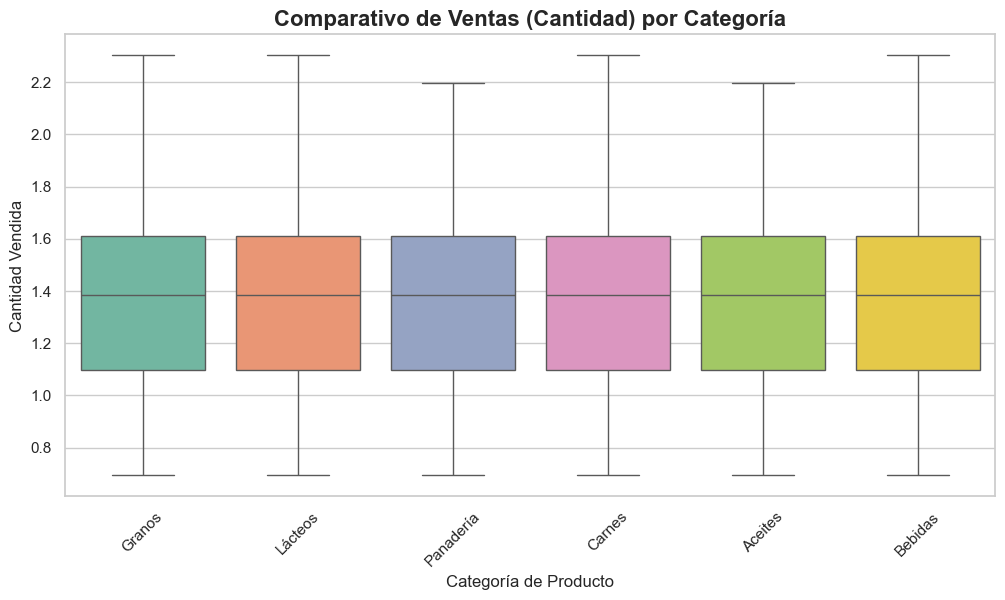

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Establezco el estilo
sns.set_theme(style="whitegrid")

# 2. Creamos el gráfico comparativo de boxplots
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='categoria',           # Eje X: Las categorías
    y='cantidad_log',            # Eje Y: La cantidad de ventas
    data=df_limpio,                 # Usamos el DF original para tener los nombres de las categorías
    hue='categoria',         # Diferenciamos colores por categoría
    palette='Set2',          # Paleta de colores suaves y profesionales
    legend=False             # Quitamos la leyenda porque ya tenemos los nombres en el eje X
)

# 3. Personalización profesional
plt.title('Comparativo de Ventas (Cantidad) por Categoría', fontsize=16, fontweight='bold')
plt.xlabel('Categoría de Producto', fontsize=12)
plt.ylabel('Cantidad Vendida', fontsize=12)
plt.xticks(rotation=45)     # Rotamos los nombres si son muy largos para que no se amontonen

plt.show()

Teóricamente tenemos un dataframe más estabilizado.

Vamos a ver cuáles son los productos que más ingresaron capital:

producto
Leche entera          18720.00
Papas precocinadas    11746.35
Pasta de Tomate        5460.00
Helado                 3847.80
Pollo                  3556.80
Jamón                  3178.80
Carne molida           2967.20
Yogurt                 2112.00
Refresco               1741.05
Bolsas                 1317.40
Name: total, dtype: float64


<Axes: title={'center': 'Productos con mayores ingresos'}, xlabel='Productos', ylabel='Total vendido ($)'>

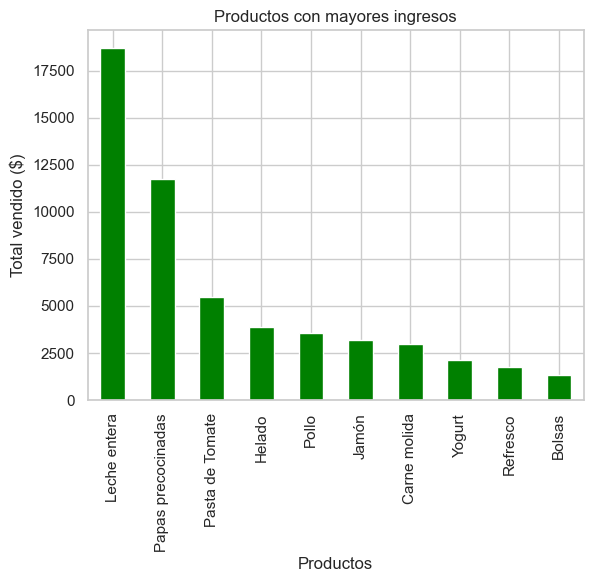

In [21]:
ingresos = df.groupby("producto")["total"].sum().sort_values(ascending=False)

print(ingresos)

ingresos.plot(kind="bar", title="Productos con mayores ingresos", ylabel="Total vendido ($)", color='green', xlabel='Productos')

Miremos la tendencia de ventas a lo largo del tiempo:

0   2023-03-26
1   2023-11-06
2   2023-07-21
3   2024-09-09
4   2024-10-25
Name: fecha, dtype: datetime64[ns]


<Axes: title={'center': 'Tendencia mensual de ingresos'}, xlabel='Meses', ylabel='Total mensual ($)'>

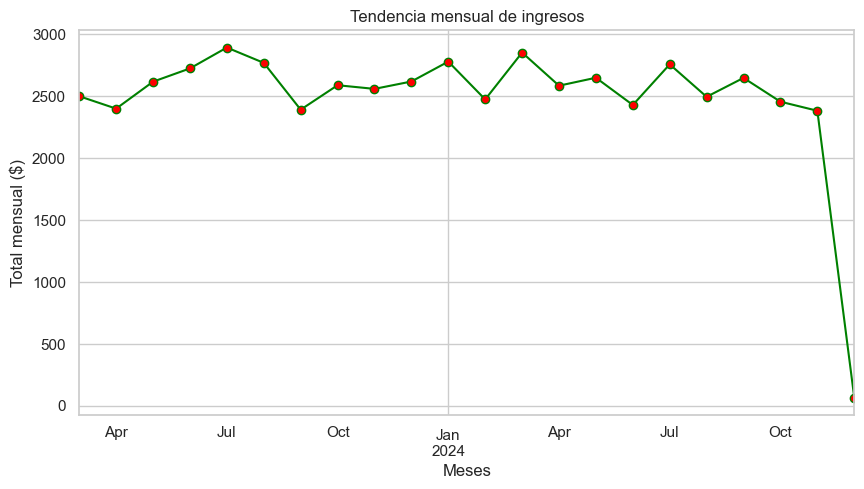

In [22]:
#Convertir la columna de fecha a datatime
df["fecha"] = pd.to_datetime(df["fecha"])
print (df["fecha"].head())
ventasxMes = df.resample("ME", on="fecha")["total"].sum()
#creamos una fracción del dataframe
ventasxMes.plot(
    kind="line",
    title="Tendencia mensual de ingresos",
    figsize=(10,5),
    ylabel="Total mensual ($)",
    xlabel="Meses",
    color="green",
    marker="o",
    markersize=6,
    markerfacecolor="red",
)

Ventas por categoría, así observamos cuál es la categoría que más vende:

In [23]:
ventasxCat = df.groupby("categoria")["fecha"].count().sort_values(ascending=True)
print(ventasxCat)

categoria
Aceites      1212
Panadería    1227
Bebidas      1258
Granos       2416
Carnes       2438
Lácteos      3552
Name: fecha, dtype: int64


<Axes: title={'center': 'Cantidad de ventas por categorías'}, xlabel='Cantidad de ventas', ylabel='Categorías'>

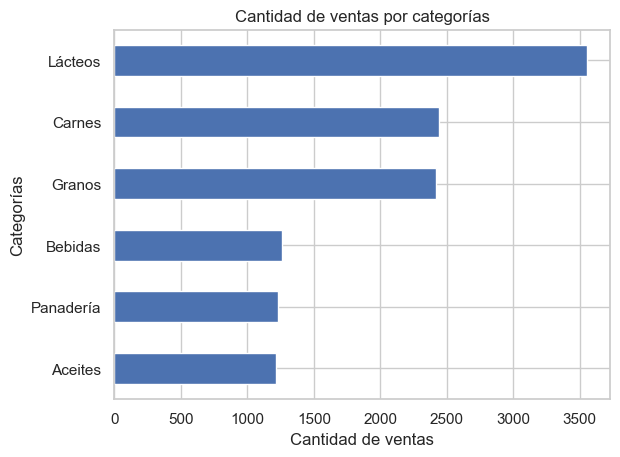

In [24]:
ventasxCat.plot(
    kind="barh",
    ylabel="Categorías",
    xlabel="Cantidad de ventas",
    title="Cantidad de ventas por categorías"
    )

**Pruebas y consultas aleatorias para mayor entendimiento del contexto por parte del Data Scientist (en este caso, yo)**

In [25]:
#Consulta de las ventas de la fehca alteatoria 2023-05-05 donde la cantidad de productos vendidos es >=5
test= df[(df["fecha"]=="2023-05-05") & (df["cantidad"]>=5)]
print(test)

          fecha  producto categoria  cantidad  precio_unitario medida  total  \
6185 2023-05-05  Refresco    Carnes         5             0.45      u   2.25   
7763 2023-05-05    Helado   Lácteos         7             1.10      u   7.70   

      cantidad_log  
6185      1.791759  
7763      2.079442  


In [26]:
#Obtener el producto más caro
test1 = df["precio_unitario"].max()

In [27]:
print(test1)

5.0


In [28]:
#Print the closest date and the furthest date from the present.
print("La fecha más actual es:          ",df["fecha"].max())
print("La fecha más antigua es:         ",df["fecha"].min())

print("Mi período de tiempo consta de:  ",df["fecha"].max()-df["fecha"].min())

La fecha más actual es:           2024-12-01 00:00:00
La fecha más antigua es:          2023-03-01 00:00:00
Mi período de tiempo consta de:   641 days 00:00:00


Prueba para ver la relación entre columnas, dado que existen varios tipos de datos en el dataframe usaré más de 1 método para observar la relación entre ellas en este EDA, comenzando con una matriz de correlación entre las columnas numéricas:

In [29]:
import seaborn as sns

print(df[['cantidad', 'precio_unitario', 'total']].corr()) #print the matrix

                 cantidad  precio_unitario     total
cantidad         1.000000         0.000932  0.414402
precio_unitario  0.000932         1.000000  0.819267
total            0.414402         0.819267  1.000000


Guardemos el df modificado en un nuevo archivo:

In [30]:
df.to_csv("procesed_data.csv")

In [31]:
import jupyter_core
print(jupyter_core.paths.jupyter_config_path())

['C:\\Users\\arizo\\anaconda3\\envs\\DataScience\\etc\\jupyter', 'C:\\Users\\arizo\\.jupyter', 'C:\\Users\\arizo\\AppData\\Roaming\\Python\\etc\\jupyter']
